In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines.utils import concordance_index

from pathlib import Path

DATA = Path("../data/processed/tcga_features.csv")
df = pd.read_csv(DATA)
print(f"Loaded {len(df):,} patients across {df['cancer_type'].nunique()} cancer types")
df.head()

Loaded 2,662 patients across 4 cancer types


,patientId,AGE,SEX,RACE,ETHNICITY,OS_MONTHS,OS_STATUS,AJCC_PATHOLOGIC_TUMOR_STAGE,event,STAGE_SIMPLE,...,mut_NSD1,mut_PIK3CA,mut_PIK3R1,mut_PTEN,mut_RB1,mut_SMAD4,mut_STK11,mut_TP53,total_mutations,mut_VHL
0,TCGA-4P-AA8J,66.0,Male,Black or African American,Not Hispanic Or Latino,3.353388,0:LIVING,STAGE IVA,0,Unknown,...,0,0,0,0,0,0,0,1,2,0
1,TCGA-BA-4074,69.0,Male,White,Not Hispanic Or Latino,15.188875,1:DECEASED,STAGE IVA,1,Unknown,...,0,0,0,1,0,0,0,1,3,0
2,TCGA-BA-4076,39.0,Male,White,Not Hispanic Or Latino,13.643686,1:DECEASED,NaN,1,Unknown,...,0,0,0,0,0,0,0,1,5,0
3,TCGA-BA-4078,83.0,Male,White,Not Hispanic Or Latino,9.073873,1:DECEASED,NaN,1,Unknown,...,0,0,0,0,0,0,0,1,3,0
4,TCGA-BA-5149,47.0,Male,White,Not Hispanic Or Latino,26.498340,1:DECEASED,STAGE IVA,1,Unknown,...,0,1,0,0,0,0,0,0,4,0


In [2]:
print("=== Survival columns ===")
print(df[["OS_MONTHS", "event", "cancer_type"]].head())
print()
print("=== Summary stats ===")
print(df.groupby("cancer_type").agg(
    n=("patientId", "count"),
    median_os=("OS_MONTHS", "median"),
    event_rate=("event", "mean"),
).round(3))

=== Survival columns ===
   OS_MONTHS  event cancer_type
0   3.353388      0        HNSC
1  15.188875      1        HNSC
2  13.643686      1        HNSC
3   9.073873      1        HNSC
4  26.498340      1        HNSC

=== Summary stats ===
                n  median_os  event_rate
cancer_type                             
BRCA         1071     27.912       0.141
COAD          568     22.044       0.204
HNSC          522     21.189       0.420
LUAD          501     21.567       0.361


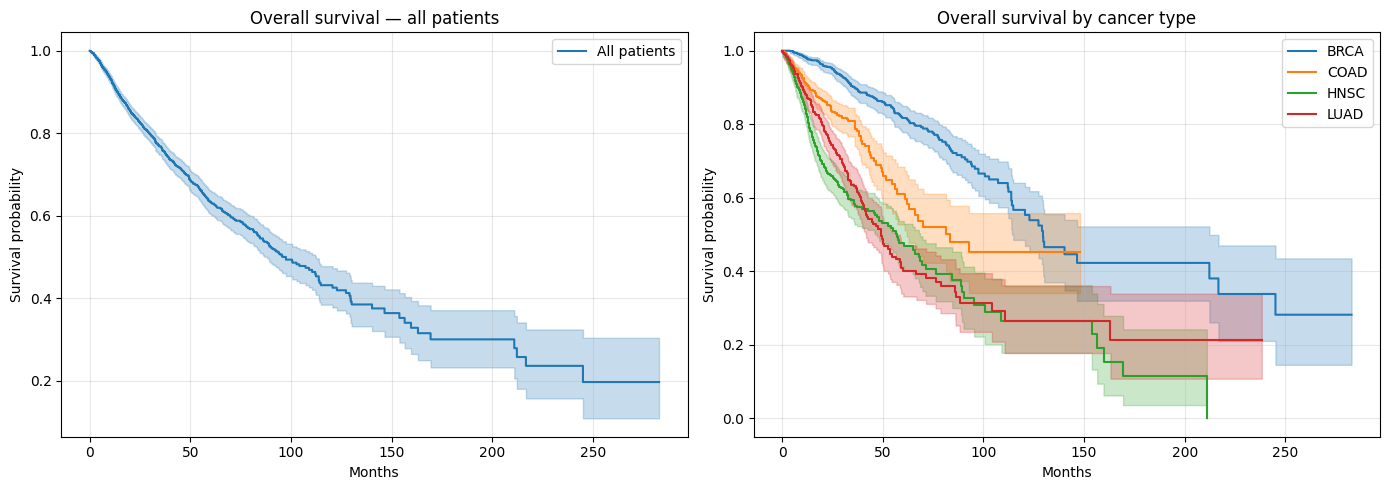

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: one overall curve
kmf = KaplanMeierFitter()
kmf.fit(df["OS_MONTHS"], df["event"], label="All patients")
kmf.plot_survival_function(ax=axes[0])
axes[0].set_title("Overall survival — all patients")
axes[0].set_xlabel("Months")
axes[0].set_ylabel("Survival probability")
axes[0].grid(alpha=0.3)

# Right: one curve per cancer type, color-coded
for cancer in sorted(df["cancer_type"].unique()):
    sub = df[df["cancer_type"] == cancer]
    kmf = KaplanMeierFitter()
    kmf.fit(sub["OS_MONTHS"], sub["event"], label=cancer)
    kmf.plot_survival_function(ax=axes[1])
axes[1].set_title("Overall survival by cancer type")
axes[1].set_xlabel("Months")
axes[1].set_ylabel("Survival probability")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
result = multivariate_logrank_test(df["OS_MONTHS"], df["cancer_type"], df["event"])
print(f"Multivariate log-rank test across cancer types:")
print(f"  Test statistic: {result.test_statistic:.2f}")
print(f"  p-value:        {result.p_value:.2e}")
print()
if result.p_value < 0.001:
    print("  -> Survival distributions are highly significantly different across cancers (p<0.001).")

Multivariate log-rank test across cancer types:
  Test statistic: 230.66
  p-value:        9.95e-50

  -> Survival distributions are highly significantly different across cancers (p<0.001).


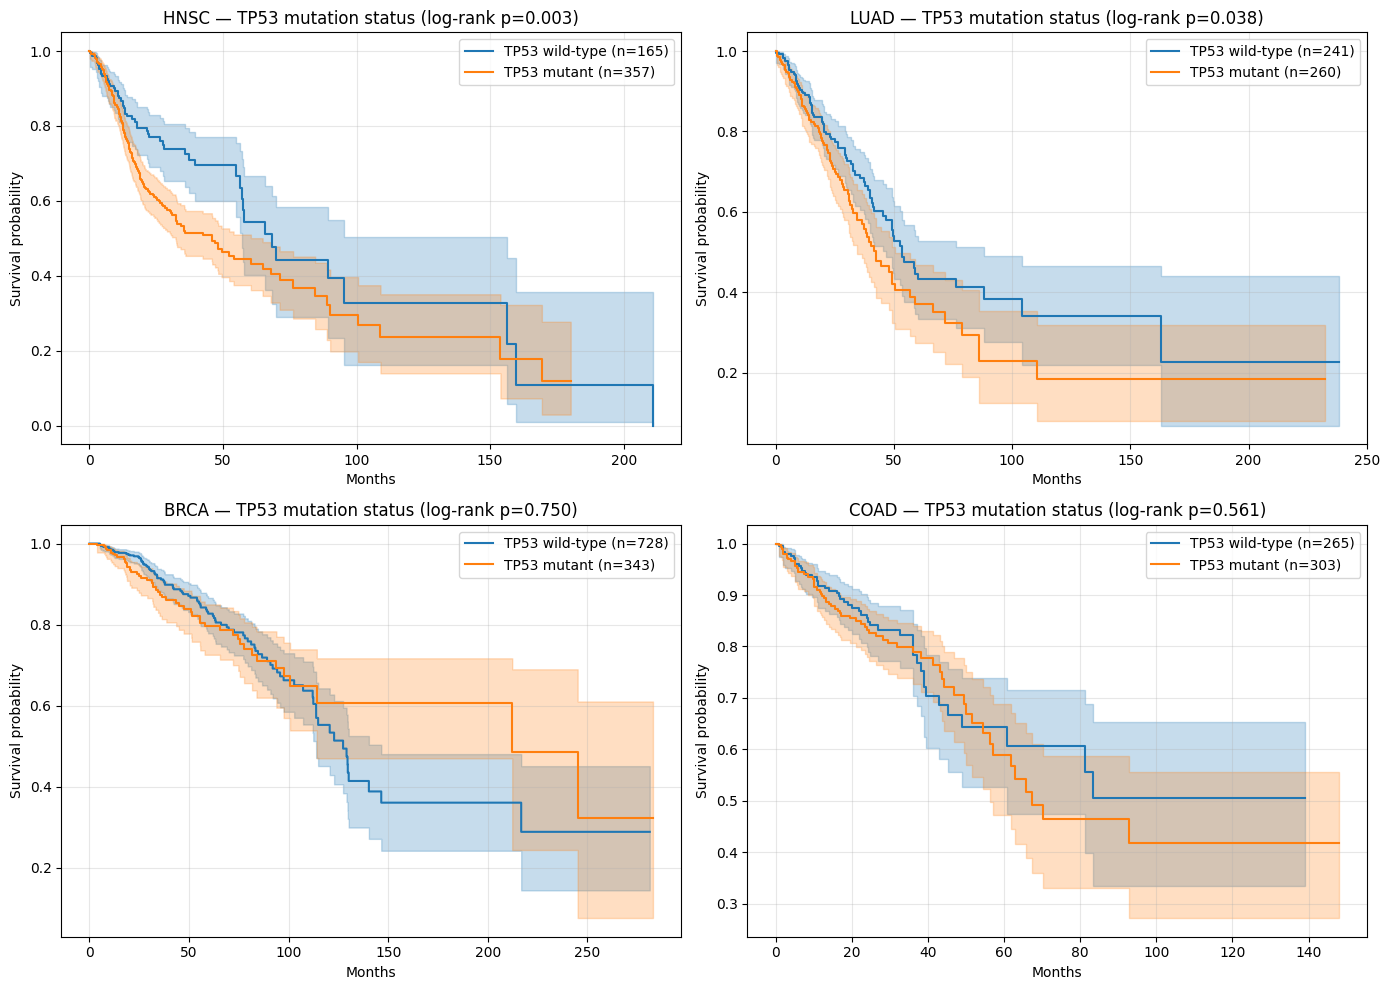

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, cancer in enumerate(["HNSC", "LUAD", "BRCA", "COAD"]):
    sub = df[df["cancer_type"] == cancer]
    if "mut_TP53" not in sub.columns:
        axes[i].text(0.5, 0.5, "No TP53 data", ha="center")
        continue

    for tp53_status in [0, 1]:
        s = sub[sub["mut_TP53"] == tp53_status]
        if len(s) < 5:
            continue
        kmf = KaplanMeierFitter()
        kmf.fit(s["OS_MONTHS"], s["event"],
                label=f"TP53 {'mutant' if tp53_status else 'wild-type'} (n={len(s)})")
        kmf.plot_survival_function(ax=axes[i], ci_show=True)

    # Log-rank p-value
    g0 = sub[sub["mut_TP53"] == 0]
    g1 = sub[sub["mut_TP53"] == 1]
    if len(g0) > 5 and len(g1) > 5:
        lr = logrank_test(g0["OS_MONTHS"], g1["OS_MONTHS"],
                          g0["event"], g1["event"])
        p = lr.p_value
    else:
        p = float("nan")

    axes[i].set_title(f"{cancer} — TP53 mutation status (log-rank p={p:.3f})")
    axes[i].set_xlabel("Months")
    axes[i].set_ylabel("Survival probability")
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
def fit_cox(df_cancer: pd.DataFrame, gene_cols: list, min_freq: int = 5):
    """Fit a Cox PH model on AGE + cancer-type-frequent gene mutations."""
    # Keep only mutations present in >= min_freq patients to avoid overfit
    freq_genes = [g for g in gene_cols if df_cancer[g].sum() >= min_freq]
    features = ["AGE"] + freq_genes
    X = df_cancer[features + ["OS_MONTHS", "event"]].dropna()

    cph = CoxPHFitter(penalizer=0.01)
    cph.fit(X, duration_col="OS_MONTHS", event_col="event")
    return cph, features


gene_cols = [c for c in df.columns if c.startswith("mut_")]

results = {}
for cancer in ["HNSC", "LUAD", "BRCA", "COAD"]:
    sub = df[df["cancer_type"] == cancer].copy()
    if len(sub) < 50:
        continue
    try:
        cph, feats = fit_cox(sub, gene_cols)
        c_index = cph.concordance_index_
        results[cancer] = {"cox": cph, "c_index": c_index, "n": len(sub),
                           "n_features": len(feats)}
        print(f"{cancer}: n={len(sub):>4d}, features={len(feats):>2d}, "
              f"C-index={c_index:.3f}")
    except Exception as e:
        print(f"{cancer}: ERROR {e}")

HNSC: n= 522, features=26, C-index=0.630
LUAD: n= 501, features=26, C-index=0.602
BRCA: n=1071, features=26, C-index=0.670
COAD: n= 568, features=28, C-index=0.639


In [7]:
def top_hazards(cph, n=10):
    s = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
    s = s.rename(columns={"exp(coef)": "HR",
                          "exp(coef) lower 95%": "HR_lo",
                          "exp(coef) upper 95%": "HR_hi"})
    # Sort by |log(HR)| so we see both protective and risky features
    s["logHR_abs"] = s["HR"].apply(lambda x: abs(np.log(x)))
    s = s.sort_values("logHR_abs", ascending=False).drop(columns="logHR_abs")
    return s.head(n)

for cancer, info in results.items():
    print(f"\n=== Top features driving survival in {cancer} (C-index={info['c_index']:.3f}) ===")
    print(top_hazards(info["cox"]).round(3))


=== Top features driving survival in HNSC (C-index=0.630) ===
               HR  HR_lo  HR_hi      p
covariate                             
mut_PIK3R1  0.315  0.049  2.020  0.223
mut_RB1     0.334  0.089  1.248  0.103
mut_PTEN    0.369  0.093  1.461  0.155
mut_TP53    1.756  1.251  2.466  0.001
mut_BRAF    0.575  0.182  1.811  0.344
mut_CASP8   1.651  1.001  2.725  0.050
mut_EGFR    1.591  0.775  3.265  0.205
mut_NSD1    0.640  0.391  1.048  0.076
mut_HRAS    0.649  0.324  1.302  0.224
mut_STK11   1.327  0.326  5.399  0.692

=== Top features driving survival in LUAD (C-index=0.602) ===
               HR  HR_lo  HR_hi      p
covariate                             
mut_MAP3K1  2.470  0.848  7.197  0.097
mut_STK11   2.001  1.320  3.034  0.001
mut_PTEN    1.715  0.622  4.725  0.297
mut_EGFR    1.701  1.067  2.711  0.026
mut_FBXW7   1.599  0.561  4.557  0.380
mut_ARID1A  1.437  0.790  2.615  0.235
mut_PIK3CA  1.433  0.813  2.528  0.214
mut_KRAS    1.363  0.959  1.937  0.084
mut_TP53    1.34

In [8]:
summary = pd.DataFrame([
    {"cancer": c, "n_patients": r["n"], "n_features": r["n_features"],
     "C_index": round(r["c_index"], 3)}
    for c, r in results.items()
])
summary

,cancer,n_patients,n_features,C_index
0,HNSC,522,26,0.630
1,LUAD,501,26,0.602
2,BRCA,1071,26,0.670
3,COAD,568,28,0.639
